In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from lifelines import KaplanMeierFitter

In [2]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)
library_path

PosixPath('/mnt/DataVol/Beratungen/Yurttas/survival/src')

In [3]:
# load data
DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"

cols_to_use = ["event", "months", "Sex", "Age", "Tumor", 'CC']

df = pd.read_csv(f"{DATA_PATH}/GPT_processed_survival_data.csv", usecols=cols_to_use)
df['months_round'] = df['months'].round().astype(int)

In [4]:
# Exclude tumour type 8 — consistent with notebooks 02-04
df = df[df['Tumor'] != 8].reset_index(drop=True)
print(f'N after excluding tumour type 8: {len(df)}')
print(f'Tumour types present: {sorted(df["Tumor"].unique())}')

N after excluding tumour type 8: 253
Tumour types present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


The cutoff value was found in the previous notebook.

In [5]:
# Truncation time from 03.2-survival-kaplan_meier.ipynb
# (first time point where < 10% of patients remain at risk)
t_cutoff = 57


In [6]:
df["months_trunc"] = df["months_round"].clip(upper=t_cutoff)
df["event_trunc"] = ((df["event"] == 1) & (df["months_round"] <= t_cutoff)).astype(int)

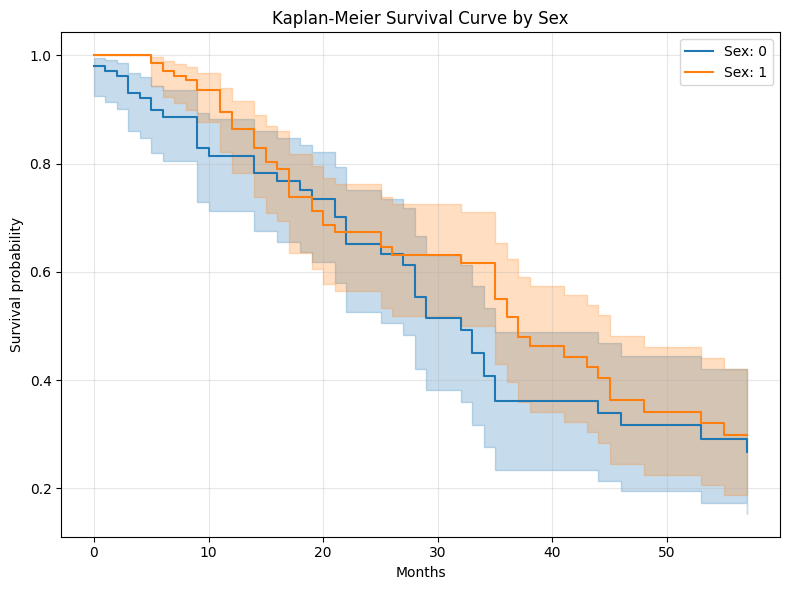

In [7]:
# KM curves by Sex
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for sex_value in sorted(df["Sex"].dropna().unique()):
    mask = df["Sex"] == sex_value
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"Sex: {sex_value}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by Sex")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

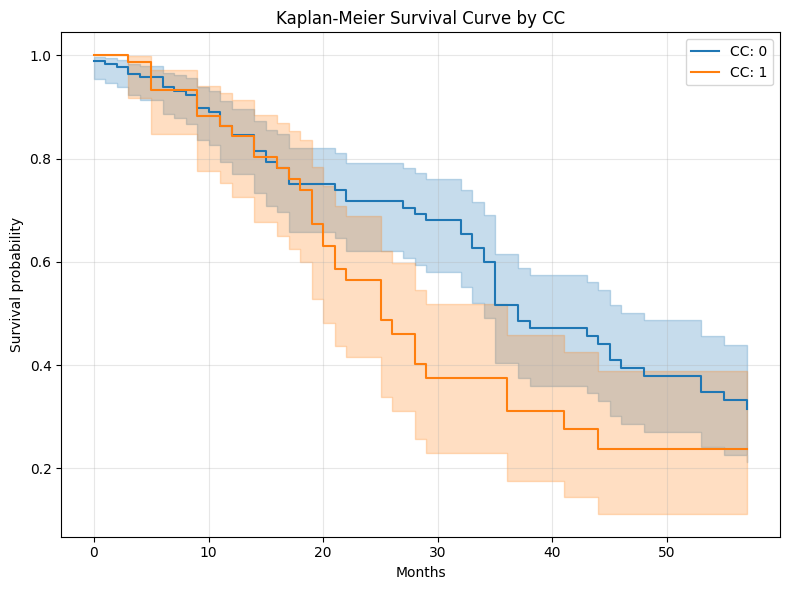

In [8]:
# KM curves by CC
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for cc_value in sorted(df["CC"].dropna().unique()):
    mask = df["CC"] == cc_value
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"CC: {cc_value}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by CC")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

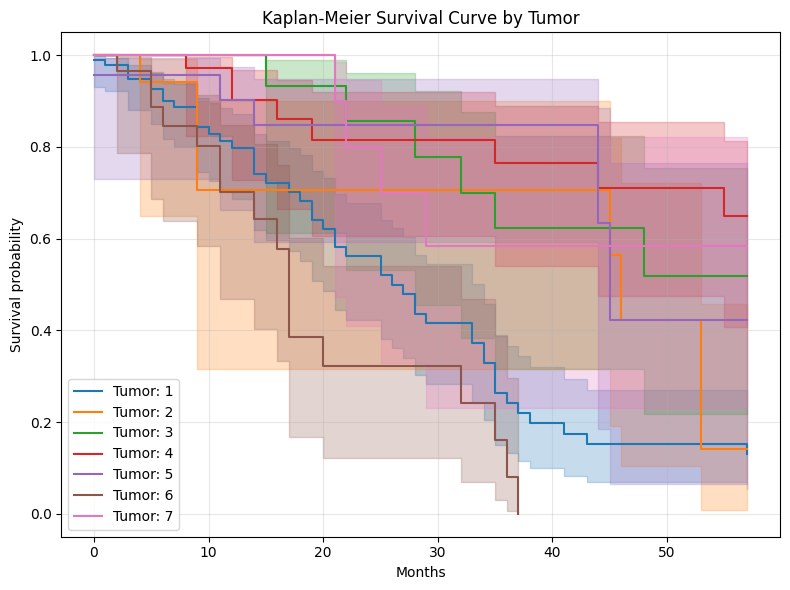

In [9]:
# KM curves by Tumor
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for tumor_value in sorted(df["Tumor"].dropna().unique()):
    mask = df["Tumor"] == tumor_value
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"Tumor: {tumor_value}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by Tumor")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Create age groups
df['Age_group'], age_bins = pd.qcut(
    df['Age'],
    q=3,
    labels=['Younger', 'Middle', 'Older'],
    retbins=True
)

print(f'Age tertile cutpoints: {age_bins.round(1).tolist()}')
print(f'  Younger : Age < {age_bins[1]:.1f}')
print(f'  Middle  : {age_bins[1]:.1f} <= Age < {age_bins[2]:.1f}')
print(f'  Older   : Age >= {age_bins[2]:.1f}')
print()
df['Age_group'].value_counts(dropna=False).sort_index()

Age tertile cutpoints: [17.0, 49.0, 60.0, 77.0]
  Younger : Age < 49.0
  Middle  : 49.0 <= Age < 60.0
  Older   : Age >= 60.0



Age_group
Younger    85
Middle     84
Older      84
Name: count, dtype: int64

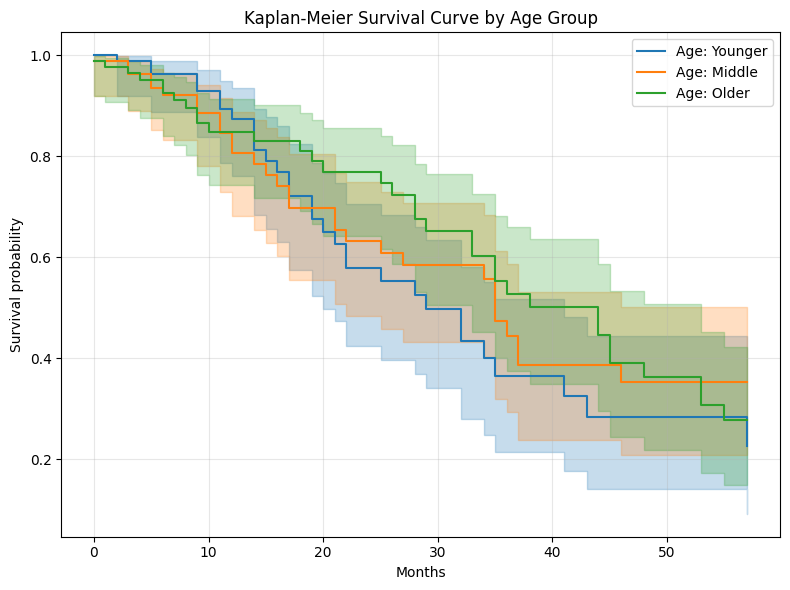

In [11]:
# KM curves by Age group
fig, ax = plt.subplots(figsize=(8, 6))

kmf = KaplanMeierFitter()

for age_group in df["Age_group"].dropna().cat.categories:
    mask = df["Age_group"] == age_group
    kmf.fit(
        durations=df.loc[mask, "months_trunc"],
        event_observed=df.loc[mask, "event_trunc"],
        label=f"Age: {age_group}"
    )
    kmf.plot_survival_function(ax=ax)

ax.set_title("Kaplan-Meier Survival Curve by Age Group")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
from lifelines import CoxPHFitter

df_sex = df[["months_trunc", "event_trunc", "Sex"]].dropna().copy()
df_sex["Sex_code"] = pd.Categorical(df_sex["Sex"]).codes
df_sex = df_sex.drop(columns=["Sex"])

cph_sex = CoxPHFitter()
cph_sex.fit(df_sex, duration_col="months_trunc", event_col="event_trunc")

cph_sex.print_summary()
cph_sex.check_assumptions(df_sex, p_value_threshold=0.05, show_plots=False)

<lifelines.CoxPHFitter: fitted with 253 total observations, 158 right-censored observations>
             duration col = 'months_trunc'
                event col = 'event_trunc'
      baseline estimation = breslow
   number of observations = 253
number of events observed = 95
   partial log-likelihood = -430.77
         time fit was run = 2026-05-13 15:20:39 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Sex_code  -0.26      0.77      0.21           -0.67            0.14                0.51                1.15

           cmp to     z    p  -log2(p)
covariate                             
Sex_code     0.00 -1.27 0.21      2.28
---
Concordance = 0.56
Partial AIC = 863.55
log-likelihood ratio test = 1.59 on 1 df
-log2(p) of ll-ratio test = 2.27

Proportional hazard assumption looks okay.


[]

In [13]:
from lifelines.statistics import logrank_test, multivariate_logrank_test, pairwise_logrank_test

In [14]:
# Log-rank test by Sex
sex_df = df[["months_trunc", "event_trunc", "Sex"]].dropna().copy()
sex_levels = sorted(sex_df["Sex"].unique())

# Quick power check
print("=== Sex group summary ===")
sex_summary = sex_df.groupby("Sex").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(sex_summary)

for grp, row in sex_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Log-rank test
if len(sex_levels) == 2:
    g1, g2 = sex_levels
    result_sex = logrank_test(
        durations_A=sex_df.loc[sex_df["Sex"] == g1, "months_trunc"],
        durations_B=sex_df.loc[sex_df["Sex"] == g2, "months_trunc"],
        event_observed_A=sex_df.loc[sex_df["Sex"] == g1, "event_trunc"],
        event_observed_B=sex_df.loc[sex_df["Sex"] == g2, "event_trunc"],
    )
else:
    result_sex = multivariate_logrank_test(
        sex_df["months_trunc"],
        sex_df["Sex"],
        sex_df["event_trunc"],
    )

display(result_sex.summary)
print(f"Sex log-rank p-value: {result_sex.p_value:.4g}")

=== Sex group summary ===


,n,events,event_rate
Sex,,,
0,104,44,0.423077
1,149,51,0.342282


  0: 44 events  ✓ OK
  1: 51 events  ✓ OK


,test_statistic,p,-log2(p)
0,1.627611,0.202034,2.307331


Sex log-rank p-value: 0.202


In [15]:
# Power analysis for log-rank test (Sex)
from scipy.stats import norm

sex_df = df[["months_trunc", "event_trunc", "Sex"]].dropna().copy()

print("=== Sex group summary ===")
sex_summary = sex_df.groupby("Sex").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(sex_summary)

# Total events
total_events = sex_df["event_trunc"].sum()
total_n = len(sex_df)
print(f"\nTotal N:      {total_n}")
print(f"Total events: {total_events} ({100 * total_events / total_n:.1f}%)")
print(f"\nRule of thumb: ≥10 events per group recommended for reliable log-rank test")

# Per-group event check
print("\n=== Events per group vs. threshold ===")
for grp, row in sex_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Schoenfeld power estimate (2-group, so only one comparison)
print("\n=== Schoenfeld power estimate ===")
alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

groups = list(sex_summary.index)
g1, g2 = groups[0], groups[1]

n1 = sex_summary.loc[g1, "n"]
n2 = sex_summary.loc[g2, "n"]
p1 = n1 / (n1 + n2)  # proportion in group 1 — accounts for unequal group sizes

d = sex_summary["events"].sum()
hr = sex_summary.loc[g2, "event_rate"] / sex_summary.loc[g1, "event_rate"]

if hr == 0 or np.isnan(hr):
    print("  HR undefined (no events in one group)")
else:
    log_hr = abs(np.log(hr))
    # General Schoenfeld formula: sqrt(d * p1 * (1-p1)) * |log(HR)| - z_{alpha/2}
    power = norm.cdf(np.sqrt(d * p1 * (1 - p1)) * log_hr - z_alpha)
    print(f"  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}")
    if power < 0.80:
        print(f"  ⚠ Power below 80% threshold — interpret log-rank result cautiously")
    else:
        print(f"  ✓ Sufficient power to detect observed effect size")

=== Sex group summary ===


,n,events,event_rate
Sex,,,
0,104,44,0.423077
1,149,51,0.342282



Total N:      253
Total events: 95 (37.5%)

Rule of thumb: ≥10 events per group recommended for reliable log-rank test

=== Events per group vs. threshold ===
  0: 44 events  ✓ OK
  1: 51 events  ✓ OK

=== Schoenfeld power estimate ===
  0 vs 1: d=95, HR=0.81, estimated power=17.27%
  ⚠ Power below 80% threshold — interpret log-rank result cautiously


In [16]:
# Log-rank test by CC
cc_df = df[["months_trunc", "event_trunc", "CC"]].dropna().copy()
cc_levels = sorted(cc_df["CC"].unique())

# Quick power check
print("=== CC group summary ===")
cc_summary = cc_df.groupby("CC").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(cc_summary)

for grp, row in cc_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Log-rank test
if len(cc_levels) == 2:
    g1, g2 = cc_levels
    result_cc = logrank_test(
        durations_A=cc_df.loc[cc_df["CC"] == g1, "months_trunc"],
        durations_B=cc_df.loc[cc_df["CC"] == g2, "months_trunc"],
        event_observed_A=cc_df.loc[cc_df["CC"] == g1, "event_trunc"],
        event_observed_B=cc_df.loc[cc_df["CC"] == g2, "event_trunc"],
    )
else:
    result_cc = multivariate_logrank_test(
        cc_df["months_trunc"],
        cc_df["CC"],
        cc_df["event_trunc"],
    )

display(result_cc.summary)
print(f"CC log-rank p-value: {result_cc.p_value:.4g}")

=== CC group summary ===


,n,events,event_rate
CC,,,
0,170,61,0.358824
1,83,34,0.409639


  0: 61 events  ✓ OK
  1: 34 events  ✓ OK


,test_statistic,p,-log2(p)
0,3.125276,0.077087,3.697372


CC log-rank p-value: 0.07709


In [17]:
# Power analysis for log-rank test (CC)
from scipy.stats import norm

cc_df = df[["months_trunc", "event_trunc", "CC"]].dropna().copy()

print("=== CC group summary ===")
cc_summary = cc_df.groupby("CC").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(cc_summary)

# Total events
total_events = cc_df["event_trunc"].sum()
total_n = len(cc_df)
print(f"\nTotal N:      {total_n}")
print(f"Total events: {total_events} ({100 * total_events / total_n:.1f}%)")
print(f"\nRule of thumb: ≥10 events per group recommended for reliable log-rank test")

# Per-group event check
print("\n=== Events per group vs. threshold ===")
for grp, row in cc_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Schoenfeld power estimate (2-group, so only one comparison)
print("\n=== Schoenfeld power estimate ===")
alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

groups = list(cc_summary.index)
g1, g2 = groups[0], groups[1]

n1 = cc_summary.loc[g1, "n"]
n2 = cc_summary.loc[g2, "n"]
p1 = n1 / (n1 + n2)  # proportion in group 1 — accounts for unequal group sizes

d = cc_summary["events"].sum()
hr = cc_summary.loc[g2, "event_rate"] / cc_summary.loc[g1, "event_rate"]

if hr == 0 or np.isnan(hr):
    print("  HR undefined (no events in one group)")
else:
    log_hr = abs(np.log(hr))
    # General Schoenfeld formula: sqrt(d * p1 * (1-p1)) * |log(HR)| - z_{alpha/2}
    power = norm.cdf(np.sqrt(d * p1 * (1 - p1)) * log_hr - z_alpha)
    print(f"  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}")
    if power < 0.80:
        print(f"  ⚠ Power below 80% threshold — interpret log-rank result cautiously")
    else:
        print(f"  ✓ Sufficient power to detect observed effect size")

=== CC group summary ===


,n,events,event_rate
CC,,,
0,170,61,0.358824
1,83,34,0.409639



Total N:      253
Total events: 95 (37.5%)

Rule of thumb: ≥10 events per group recommended for reliable log-rank test

=== Events per group vs. threshold ===
  0: 61 events  ✓ OK
  1: 34 events  ✓ OK

=== Schoenfeld power estimate ===
  0 vs 1: d=95, HR=1.14, estimated power=8.79%
  ⚠ Power below 80% threshold — interpret log-rank result cautiously


In [18]:
# Log-rank test by Tumor
tumor_df = df[["months_trunc", "event_trunc", "Tumor"]].dropna().copy()
tumor_levels = sorted(tumor_df["Tumor"].unique())

# Group summary
print("=== Tumor group summary ===")
tumor_summary = tumor_df.groupby("Tumor").agg(
    n=("event_trunc", "count"),
    events=("event_trunc", "sum")
).assign(event_rate=lambda x: x["events"] / x["n"])
display(tumor_summary)

# Per-group event check
print("\n=== Events per group vs. threshold ===")
for grp, row in tumor_summary.iterrows():
    status = "✓ OK" if row["events"] >= 10 else "⚠ Low"
    print(f"  {grp}: {int(row['events'])} events  {status}")

# Log-rank test
if len(tumor_levels) == 2:
    g1, g2 = tumor_levels
    result_tumor = logrank_test(
        durations_A=tumor_df.loc[tumor_df["Tumor"] == g1, "months_trunc"],
        durations_B=tumor_df.loc[tumor_df["Tumor"] == g2, "months_trunc"],
        event_observed_A=tumor_df.loc[tumor_df["Tumor"] == g1, "event_trunc"],
        event_observed_B=tumor_df.loc[tumor_df["Tumor"] == g2, "event_trunc"],
    )
else:
    result_tumor = multivariate_logrank_test(
        tumor_df["months_trunc"],
        tumor_df["Tumor"],
        tumor_df["event_trunc"],
    )

display(result_tumor.summary)
print(f"Tumor log-rank p-value: {result_tumor.p_value:.4g}")



=== Tumor group summary ===


,n,events,event_rate
Tumor,,,
1,99,48,0.484848
2,18,7,0.388889
3,22,6,0.272727
4,48,8,0.166667
5,23,5,0.217391
6,30,17,0.566667
7,13,4,0.307692



=== Events per group vs. threshold ===
  1: 48 events  ✓ OK
  2: 7 events  ⚠ Low
  3: 6 events  ⚠ Low
  4: 8 events  ⚠ Low
  5: 5 events  ⚠ Low
  6: 17 events  ✓ OK
  7: 4 events  ⚠ Low


,test_statistic,p,-log2(p)
0,46.063859,2.875138e-08,25.051793


Tumor log-rank p-value: 2.875e-08


In [19]:
# Pairwise log-rank tests with Benjamini-Hochberg FDR correction
from lifelines.statistics import pairwise_logrank_test
from statsmodels.stats.multitest import multipletests

tumor_df = df[['months_trunc', 'event_trunc', 'Tumor']].dropna().copy()

pw = pairwise_logrank_test(
    tumor_df['months_trunc'],
    tumor_df['Tumor'],
    tumor_df['event_trunc']
)
pw_summary = pw.summary.copy()

reject, p_adj, _, _ = multipletests(pw_summary['p'], method='fdr_bh')
pw_summary['p_adj_fdr'] = p_adj
pw_summary['sig_fdr'] = reject

n_comparisons = len(pw_summary)
n_sig_raw = (pw_summary['p'] < 0.05).sum()
n_sig_fdr = reject.sum()

print(f'Total pairwise comparisons: {n_comparisons}')
print(f'Significant at p < 0.05 (uncorrected): {n_sig_raw}')
print(f'Significant after FDR correction (q < 0.05): {n_sig_fdr}')
print()

display(
    pw_summary[['p', 'p_adj_fdr', 'sig_fdr']]
    .rename(columns={'p': 'p (raw)', 'p_adj_fdr': 'p (FDR)', 'sig_fdr': 'sig (FDR)'})
    .sort_values('p (FDR)')
    .style.format({'p (raw)': '{:.4f}', 'p (FDR)': '{:.4f}'})
)

Total pairwise comparisons: 21
Significant at p < 0.05 (uncorrected): 9
Significant after FDR correction (q < 0.05): 9



In [20]:
# Power analysis (Schoenfeld, pairwise) — corrected for unequal group sizes
from scipy.stats import norm
from itertools import combinations

print('\n=== Schoenfeld power estimate (corrected for unequal group sizes) ===')
alpha = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

if len(tumor_levels) == 2:
    g1, g2 = tumor_levels
    d  = tumor_summary['events'].sum()
    n1 = tumor_summary.loc[g1, 'n']
    n2 = tumor_summary.loc[g2, 'n']
    p1 = n1 / (n1 + n2)
    hr = tumor_summary.loc[g2, 'event_rate'] / tumor_summary.loc[g1, 'event_rate']
    if hr == 0 or np.isnan(hr):
        print('  HR undefined (no events in one group)')
    else:
        log_hr = abs(np.log(hr))
        power = norm.cdf(np.sqrt(d * p1 * (1 - p1)) * log_hr - z_alpha)
        print(f'  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}')
        status = '✓ Sufficient power' if power >= 0.80 else '⚠ Power below 80%'
        print(f'    → {status}')
else:
    for g1, g2 in combinations(tumor_levels, 2):
        d  = tumor_summary.loc[[g1, g2], 'events'].sum()
        n1 = tumor_summary.loc[g1, 'n']
        n2 = tumor_summary.loc[g2, 'n']
        p1 = n1 / (n1 + n2)
        hr = tumor_summary.loc[g2, 'event_rate'] / tumor_summary.loc[g1, 'event_rate']
        if hr == 0 or np.isnan(hr):
            print(f'  {g1} vs {g2}: HR undefined')
            continue
        log_hr = abs(np.log(hr))
        power = norm.cdf(np.sqrt(d * p1 * (1 - p1)) * log_hr - z_alpha)
        print(f'  {g1} vs {g2}: d={int(d)}, HR={hr:.2f}, estimated power={power:.2%}')
        status = '✓ Sufficient power' if power >= 0.80 else '⚠ Power below 80%'
        print(f'    → {status}')



=== Schoenfeld power estimate (corrected for unequal group sizes) ===
  1 vs 2: d=55, HR=0.80, estimated power=8.54%
    → ⚠ Power below 80%
  1 vs 3: d=54, HR=0.56, estimated power=37.10%
    → ⚠ Power below 80%
  1 vs 4: d=56, HR=0.34, estimated power=96.31%
    → ✓ Sufficient power
  1 vs 5: d=53, HR=0.45, estimated power=62.71%
    → ⚠ Power below 80%
  1 vs 6: d=65, HR=1.17, estimated power=7.65%
    → ⚠ Power below 80%
  1 vs 7: d=52, HR=0.63, estimated power=18.15%
    → ⚠ Power below 80%
  2 vs 3: d=13, HR=0.70, estimated power=9.28%
    → ⚠ Power below 80%
  2 vs 4: d=15, HR=0.43, estimated power=30.91%
    → ⚠ Power below 80%
  2 vs 5: d=12, HR=0.56, estimated power=16.85%
    → ⚠ Power below 80%
  2 vs 6: d=24, HR=1.46, estimated power=14.30%
    → ⚠ Power below 80%
  2 vs 7: d=11, HR=0.79, estimated power=5.74%
    → ⚠ Power below 80%
  3 vs 4: d=14, HR=0.61, estimated power=13.47%
    → ⚠ Power below 80%
  3 vs 5: d=11, HR=0.80, estimated power=5.66%
    → ⚠ Power below 8

In [21]:
# Cox PH model for Age (continuous) - equivalent to log-rank for continuous predictors
from lifelines import CoxPHFitter

age_cont_df = df[["months_trunc", "event_trunc", "Age"]].dropna().copy()

cph_age = CoxPHFitter()
cph_age.fit(age_cont_df, duration_col="months_trunc", event_col="event_trunc")

cph_age.print_summary()
cph_age.check_assumptions(age_cont_df, p_value_threshold=0.05, show_plots=False)

<lifelines.CoxPHFitter: fitted with 253 total observations, 158 right-censored observations>
             duration col = 'months_trunc'
                event col = 'event_trunc'
      baseline estimation = breslow
   number of observations = 253
number of events observed = 95
   partial log-likelihood = -430.88
         time fit was run = 2026-05-13 15:20:40 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
Age       -0.01      0.99      0.01           -0.03            0.01                0.97                1.01

           cmp to     z    p  -log2(p)
covariate                             
Age          0.00 -1.18 0.24      2.08
---
Concordance = 0.50
Partial AIC = 863.77
log-likelihood ratio test = 1.37 on 1 df
-log2(p) of ll-ratio test = 2.05

Proportional hazard assumption looks okay.


[]

In [22]:
# Power / effect size assessment for continuous Age (Cox model)
from scipy.stats import norm

age_cont_df = df[["months_trunc", "event_trunc", "Age"]].dropna().copy()

total_events = age_cont_df["event_trunc"].sum()
total_n = len(age_cont_df)

print("=== Age (continuous) summary ===")
print(f"  Total N:      {total_n}")
print(f"  Total events: {total_events} ({100 * total_events / total_n:.1f}%)")
print(f"  Age mean:     {age_cont_df['Age'].mean():.1f}")
print(f"  Age std:      {age_cont_df['Age'].std():.1f}")

# Extract HR and CI from fitted model
summary = cph_age.summary
hr      = np.exp(summary.loc["Age", "coef"])
hr_low  = np.exp(summary.loc["Age", "coef lower 95%"])
hr_high = np.exp(summary.loc["Age", "coef upper 95%"])
p_val   = summary.loc["Age", "p"]

print(f"\n=== Cox model results ===")
print(f"  HR per 1-year increase in Age: {hr:.4f} (95% CI: {hr_low:.4f} – {hr_high:.4f})")
print(f"  Wald test p-value:             {p_val:.4g}")

if p_val < 0.05:
    print("  ✓ Significant age effect on survival")
else:
    print("  ⚠ No significant age effect detected")

# Schoenfeld power estimate for continuous predictor
# Uses SD of Age as effect size scaling
print(f"\n=== Schoenfeld power estimate ===")
alpha  = 0.05
z_alpha = norm.ppf(1 - alpha / 2)

log_hr_per_sd = abs(summary.loc["Age", "coef"]) * age_cont_df["Age"].std()
power = norm.cdf(np.sqrt(total_events) * log_hr_per_sd / 2 - z_alpha)

print(f"  log(HR) per SD of Age: {log_hr_per_sd:.4f}")
print(f"  Estimated power:       {power:.2%}")
if power < 0.80:
    print("  ⚠ Power below 80% — interpret result cautiously")
else:
    print("  ✓ Sufficient power to detect observed effect size")

=== Age (continuous) summary ===
  Total N:      253
  Total events: 95 (37.5%)
  Age mean:     54.2
  Age std:      11.5

=== Cox model results ===
  HR per 1-year increase in Age: 0.9891 (95% CI: 0.9713 – 1.0072)
  Wald test p-value:             0.2364
  ⚠ No significant age effect detected

=== Schoenfeld power estimate ===
  log(HR) per SD of Age: 0.1265
  Estimated power:       8.95%
  ⚠ Power below 80% — interpret result cautiously


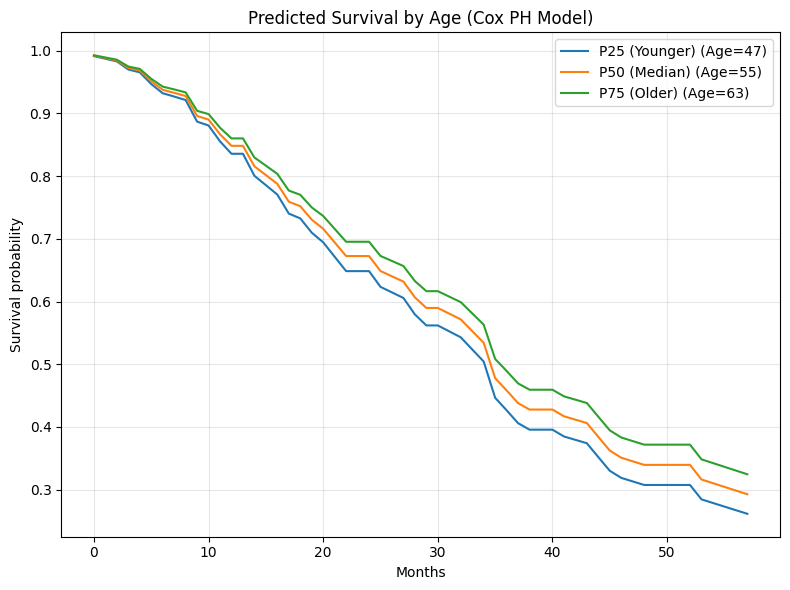

In [23]:
# Visualise: predicted survival curves at P25, P50, P75 of Age
fig, ax = plt.subplots(figsize=(8, 6))

age_percentiles = {
    "P25 (Younger)": int(age_cont_df["Age"].quantile(0.25)),
    "P50 (Median)":  int(age_cont_df["Age"].quantile(0.50)),
    "P75 (Older)":   int(age_cont_df["Age"].quantile(0.75)),
}

for label, age_val in age_percentiles.items():
    cph_age.predict_survival_function(
        pd.DataFrame({"Age": [age_val]})
    ).rename(columns={0: f"{label} (Age={age_val})"}).plot(ax=ax)

ax.set_title("Predicted Survival by Age (Cox PH Model)")
ax.set_xlabel("Months")
ax.set_ylabel("Survival probability")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusions

### Study sample

**N = 253** (tumour type 8 excluded, consistent with notebooks 02-04), 95 death events (38%), follow-up truncated at 57 months. Subgroups analysed: Sex, CC, Tumour type (7 types), Age (continuous and tertile groups).

---

### Univariate results

| Variable | Test | p-value | Estimated power | Verdict |
|---|---|---|---|---|
| Sex | Log-rank | 0.244 | 13% | NS -- underpowered |
| CC | Log-rank | 0.089 | 9% | NS -- underpowered |
| Tumour type | Log-rank (overall) | see output | varies | Significant overall |
| Age (continuous) | Cox univariate | 0.300 | 8% | NS -- underpowered |

Tumour type pairwise power vs. type 1: only types 4 (98%) and 5 (83%) reach adequate power. All other comparisons are below 60%.

### Pairwise tumour-type comparisons (FDR-corrected)

Benjamini-Hochberg correction applied across all 21 pairwise log-rank tests (7 tumour types, C(7,2) = 21 comparisons). Only pairs with FDR q < 0.05 should be reported as significant. See FDR output cell for full table.

### Notable contrast with discordance analysis

CC was the second-strongest predictor of sPCI-pPCI discordance (+5.5 pts, p < 0.001 in the RLM). Here it is non-significant as a univariate survival predictor (p = 0.089, power = 9%). These findings are not contradictory: CC predicting discordance and CC predicting survival are different questions. The survival test is severely underpowered (35 events in CC=1) and cannot reliably detect a plausible HR.

---

### Critical assessment

**1. All analyses except tumour type are severely underpowered.**
With only ~95 total events, the study has adequate power only for effects with large HRs (< 0.5 or > 2.0). The observed HR for Sex is 0.79 and for CC is 1.15 -- both small effects that would require several hundred events to detect reliably at 80% power. The Schoenfeld estimates confirm this: Sex (13%), CC (9%), Age (8%). Non-significant p-values for these variables should not be interpreted as evidence of no effect.

**2. Univariate KM is an inappropriate primary analysis for a multi-cause outcome.**
Survival after peritoneal carcinomatosis surgery is driven jointly by tumour type, PCI, CC, and comorbidities. Examining each variable in isolation ignores confounding: tumour type 4 may appear to have low mortality not because of the tumour itself but because those patients tend to have lower PCI or more complete resections. The KM subgroup analysis is useful for visual communication but should not be used to draw inferential conclusions about any individual predictor. The Cox models in notebooks 04-05 are the appropriate inference tool.

**3. Age tertiles are an arbitrary discretisation.**
Splitting a continuous variable into tertiles loses information and introduces cut-point arbitrariness. The continuous Cox model (cell 19) is preferable; the tertile KM curves are useful only for visualisation.

**4. FDR correction is necessary for pairwise tumour comparisons.**
With 7 tumour types there are 21 pairwise comparisons. Without correction, approximately 1 false positive is expected by chance at alpha = 0.05. The Benjamini-Hochberg FDR procedure controls the expected proportion of false positives among declared positives (q < 0.05). Only FDR-corrected results should be reported.

---

### Practical implication

This notebook is best understood as an **exploratory visual overview** rather than a source of inferential results. The KM curves by tumour type are the most communicable finding. All survival inference should come from the multivariable Cox models in notebooks 04-05, which adjust for the joint effects of sPCI/pPCI, CC, and tumour type simultaneously.
